**Test with Iris dataset and Test, Validation and Train split function**

In [66]:
# Aluno: Nicholas Barbosa e Costa
# Matrícula: 95667

from sklearn.datasets import load_iris # carrega o dataset Iris
from sklearn.model_selection import train_test_split # divide o dataset em treino e teste
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay   # matriz de confusão para avaliar o modelo

import numpy as np

import torch
import torch.nn as nn

from torchsummary import summary # resumo do modelo
from torch.utils.tensorboard import SummaryWriter # visualização de métricas no TensorBoard

from datetime import datetime

import matplotlib.pyplot as plt
import copy
from tqdm import tqdm

SEED = 95667

np.random.seed(SEED)
torch.manual_seed(SEED)

# Se estiver usando GPU Apple (MPS):
torch.mps.manual_seed(SEED)

In [67]:
iris = load_iris() # carrega o dataset Iris
X, y = iris.data, iris.target # dados de entrada e as respectivas labels

# divisão do data set em treino e teste
X_train_val,X_test,y_train_val,y_test=train_test_split(X,y,test_size=0.15,random_state=SEED)

# divide o conjunto de treino em treino e validação
# 1 fold de validacao e 4 folds de treino
# o modelo eh avaliado em cada epoca no conjunto de validacao (20% do conjunto de treino)
X_train,X_val,y_train,y_val=train_test_split(X_train_val,y_train_val,test_size=0.2,random_state=SEED)

# descreve cada flor com 4 medidas: comprimento e largura da sépala, comprimento e largura da pétala
# a label eh a especie {0,1,2} pre-definida no dataset
print(f'Treino: Dados {X_train.shape} Rótulos {y_train.shape}')
print(f'Validação: {X_val.shape} Rótulos {y_val.shape}')
print(f'Teste: {X_test.shape} Rótulos {y_test.shape}')

print(f'Exemplo de dado de treino:    Dados {X_train[1]} Rótulo {y_train[1]}')
print(f'Exemplo de dado de validação: Dados {X_val[1]} Rótulo {y_val[1]}')
print(f'Exemplo de dado de teste:     Dados {X_test[1]} Rótulo {y_test[1]}')

# organizacao do dataset em um dicionário para facilitar o acesso
dataset = {}
dataset['train'] = {'data':X_train, 'label':y_train}
dataset['val']   = {'data':X_val, 'label':y_val}
dataset['test']  = {'data':X_test, 'label':y_test}
dataset['class_labels'] = [iris.target_names[0], iris.target_names[1], iris.target_names[2]]

Treino: Dados (101, 4) Rótulos (101,)
Validação: (26, 4) Rótulos (26,)
Teste: (23, 4) Rótulos (23,)
Exemplo de dado de treino:    Dados [5.7 2.8 4.5 1.3] Rótulo 1
Exemplo de dado de validação: Dados [5.5 2.6 4.4 1.2] Rótulo 1
Exemplo de dado de teste:     Dados [6.7 3.1 4.4 1.4] Rótulo 1


### Architecture definition

In [68]:
#define ANN architecture as a Torch NN Module
class ANN(nn.Module):
    # define a arquitetura da rede neural
    def __init__(self, num_classes=3):
        super().__init__()
        self.lin1 = nn.Linear(4, 8)  # 4 neuronios de entrada e 8 neuronios na primeira camada oculta
        self.act1 = nn.ELU() # camada de ativacao para a saida da primeira camada oculta
        self.lin2 = nn.Linear(8, 8) # 8 neuronios da primeira camada oculta e 8 neuronios na segunda camada oculta
        self.act2 = nn.ELU() # camada de ativacao para a saida da segunda camada oculta
        self.lin3 = nn.Linear(8, 8) # 8 neuronios da segunda camada oculta e 8 neuronios na terceira camada oculta
        self.act3 = nn.ELU() # camada de ativacao para a saida da terceira camada oculta
        self.lin4 = nn.Linear(8, num_classes) # 8 neuronios da terceira camada e 3 saídas, que é a classe prevista pelo modelo
        
    def forward(self, x, debug=False):
        if debug : print(f'Shape de entrada: {x.shape}')
        x = self.lin1(x) # somatorio(w_i*x_i) + b --> 8 neuronios de saida
        if debug : print(f'Shape de entrada: {x.shape}')
        x = self.act1(x) # ativa a saida de cada neuronio da primeira camada oculta - a saida eh ELU(somatorio(w_i*x_i) + b)
        if debug : print(f'Shape de entrada: {x.shape}')
        x = self.lin2(x) # somatorio(w_i*x_i) + b --> 8 neuronios de saida, sendo x_i a saida de cada neuronio da primeira camada oculta
        if debug : print(f'Shape de entrada: {x.shape}')
        x = self.act2(x) # ativa a saida de cada neuronio da segunda camada oculta - a saida eh ELU(somatorio(w_i*x_i) + b)
        if debug : print(f'Shape de entrada: {x.shape}')
        x = self.lin3(x) # somatorio(w_i*x_i) + b --> 8 neuronios de saida, sendo x_i a saida de cada neuronio da segunda camada oculta
        if debug : print(f'Shape de entrada: {x.shape}')
        x = self.act3(x) # ativa a saida de cada neuronio da terceira camada oculta - a saida eh ELU(somatorio(w_i*x_i) + b)
        if debug : print(f'Shape de entrada: {x.shape}')
        y = self.lin4(x) # somatorio(w_i*x_i) + b --> 3 neuronios de saida, sendo x_i a saida de cada neuronio da terceira camada oculta. Cada neuronio de saida representa a pontuacao para cada classe
        if debug : print(f'Shape de entrada: {y.shape}')
        return y         

### Model analysis

In [69]:
if torch.backends.mps.is_available():
    my_device = torch.device("mps")
elif torch.cuda.is_available():
    my_device = torch.device("cuda:0")
else:
    my_device = torch.device("cpu")

print(f"Running on {my_device.type}.")

net = ANN( num_classes=3 ) # instancia a rede neural

# move o modelo para o dispositivo selecionado (GPU ou CPU)
net = net.to(my_device)

# resumo do modelo
a = torch.rand( (1, 4) )
a = a.to(my_device)
b = net( a , debug=True)

del a, b, net

Running on mps.
Shape de entrada: torch.Size([1, 4])
Shape de entrada: torch.Size([1, 8])
Shape de entrada: torch.Size([1, 8])
Shape de entrada: torch.Size([1, 8])
Shape de entrada: torch.Size([1, 8])
Shape de entrada: torch.Size([1, 8])
Shape de entrada: torch.Size([1, 8])
Shape de entrada: torch.Size([1, 3])


In [70]:
from torchinfo import summary

net = ANN( num_classes=3 )

net = net.to(my_device)

print(summary(net, input_size=(1, 4))) # print do summary do modelo, usando mps da apple

del net

Layer (type:depth-idx)                   Output Shape              Param #
ANN                                      [1, 3]                    --
├─Linear: 1-1                            [1, 8]                    40
├─ELU: 1-2                               [1, 8]                    --
├─Linear: 1-3                            [1, 8]                    72
├─ELU: 1-4                               [1, 8]                    --
├─Linear: 1-5                            [1, 8]                    72
├─ELU: 1-6                               [1, 8]                    --
├─Linear: 1-7                            [1, 3]                    27
Total params: 211
Trainable params: 211
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


### Training functions

In [71]:
def validate ( model , dataset , device='cpu', criterion=None, confusion_matrix_labels=None) :

    # converte os dados para tensores e move para o dispositivo selecionado (GPU ou CPU)
    x = torch.from_numpy(dataset['data']).float()
    x = x.to(device)
    label = torch.from_numpy(dataset['label']).float()
    label = label.to(device)

    # coloca o modelo em modo de avaliação
    model.eval()

    predict_y = model( x ).detach() # faz a predição do modelo para cada exemplo do dataset. descarta o historico de gradiente, pois nao é necessário fazer backpropagation durante a validação 
    predict_ys = torch.max( predict_y, axis=1 )[1] # pega a label prevista de cada amostra
    correct = torch.sum(predict_ys == label) # compara a previsao com a label verdadeira

    accuracy = correct.to('cpu').numpy()*100./x.size(0) # calculo da acuracia media 

    # mostra onde o modelo errou, usando a matriz de confusão
    # diagonal mostra os acertos
    if confusion_matrix_labels != None :
        disp = ConfusionMatrixDisplay(
            confusion_matrix= confusion_matrix(label.cpu(), predict_ys.cpu()), 
            display_labels=confusion_matrix_labels
        )
        disp.plot(cmap='Blues')
        plt.show()
    
    # se for validacao, retorna so a acuracia 
    if criterion == None:
        return accuracy

    # calcula a loss do modelo
    error = criterion( predict_y , label.long() ) 

    return accuracy, error

In [72]:
def plot_layers ( net , writer, epoch ) : # registra no tensorboard os pesos, bias e gradientes de cada camada linear do modelo a cada epoca de treinamento
    layers = list(net.modules()) # lista todas as camadas da rede neural

    layer_id = 1 
    for layer in layers:
        if isinstance(layer, nn.Linear) : # filtra apenas as camadas lineares
            writer.add_histogram(f'Bias/linear-{layer_id}', layer.bias, epoch )
            writer.add_histogram(f'Weight/linear-{layer_id}', layer.weight, epoch )
            writer.add_histogram(f'Grad/linear-{layer_id}', layer.weight.grad, epoch )
            layer_id += 1

In [ ]:
from enum import Enum
import math

class update_params_type(Enum):
    per_epoch = 0
    per_sample = 1
    per_5_batch = 2

''''
dataset: conjunto dos dados
prefix: nome da pasta de logs no TensorBoard, se for none, usa data/hora atual
upper_bound: acurácia máxima para parar o treinamento
save: se True, salva o melhor modelo em disco
epochs: número de épocas de treinamento
lr: learning rate
device: dispositivo para treinamento (cpu ou gpu)
debug: se True, exibe informações de debug
layers2tensorboard: se True, registra os pesos e bias no TensorBoard
lambda_reg: parâmetro de regularização L2
update_params: tipo de atualização dos parâmetros (por época, por amostra ou por batch)
'''
def train ( dataset, prefix=None, upper_bound=101.0, save=False, epochs=100, 
           lr=1e-1, device='cpu', debug=False, layers2tensorboard=True, lambda_reg=0, update_params=update_params_type.per_epoch ) :
    
    num_classes = 3 # possiveis classes do dataset Iris: setosa, versicolor e virginica
    
    # caminho para salvar os logs do TensorBoard
    tensorboard_path = '/Users/nicholasbarbosa/Mestrado/inf692/atividade-curta-4/runs/'

    # instacia a rede neural
    net = ANN( num_classes )
    net.to(device)

    '''
    usa SGD para atualizar os pesos do modelo    
    net.parameters(): retorna pesos e bias que serao atualizados durante o treinamento
    lr: a taxa de aprendizado, controla quanto os pesos sao atualizados a cada ajuste de parametro
    weight_decay é o parâmetro de regularização L2, que penaliza pesos grandes para evitar overfitting.
    '''
    optimizer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=lambda_reg)

    # calcula a loss media
    criterion = nn.CrossEntropyLoss()

    now = datetime.now()
    suffix = now.strftime("%Y%m%d_%H%M%S")
    prefix = suffix if prefix is None else prefix + '-' + suffix  

    # objeto para escrever os logs no tensorBoard
    writer = SummaryWriter( log_dir=tensorboard_path+prefix )
    
    
    accuracies = [] # para plotar o grafico de acuracias ao longo do treinamento
    max_accuracy = -1.0  # guarda a maior acuracia durante o treinamento para salvar o melhor modelo 
    
    # converte os dados para tensores e move para o dispositivo selecionado (GPU ou CPU)
    train_x = torch.from_numpy(dataset['train']['data']).float()
    train_x = train_x.to(device)
    train_label = torch.from_numpy(dataset['train']['label']).float()
    train_label = train_label.to(device)
    
    writer.add_graph(net, train_x)


    # loop de treinamento
    for epoch in tqdm( range(epochs) , desc='Training epochs...' ) :
        
        # Set Pytorch variables
        net.train() # coloca o modelo em modo de treinamento

        if update_params == update_params_type.per_sample :
            for i in range(train_x.size(0)) : # loop para treinar o modelo amostra por amostra
                optimizer.zero_grad() # zera os gradientes acumulados dos pesos e bias, para evitar que os gradientes se acumulem ao longo das épocas
                            
                # Forward step
                predict_yi = net( train_x[i].unsqueeze(0) ) # resultado da predicao do modelo para a amostra i
                
                # Loss
                error = criterion( predict_yi , train_label[i].unsqueeze(0).long() ) # calculo da loss do modelo para a amostra i

                # Back propagation
                error.backward() # calculo dos gradientes
                optimizer.step() # usa os gradientes para atualizar os pesos -- peso_novo = peso_atual - lr × gradiente
            
            with torch.no_grad(): # desabilita o calculo de gradiente
                predict_y = net(train_x) # resultado da predicao do modelo, usado para calcular as acuracias e loss do modelo no conjunto de treino e validacao

        elif update_params == update_params_type.per_5_batch :
            batch_size = math.ceil(train_x.size(0) / 5) # divide o conjunto de treinos em 5 batches

            for i in range(0, train_x.size(0), batch_size) :
                batch_x = train_x[i:i+batch_size]    
                batch_label = train_label[i:i+batch_size] 

                optimizer.zero_grad()

                predict_yi = net( batch_x ) # resultado da predicao do modelo para a amostra i
                error = criterion( predict_yi , batch_label.long() ) # calculo da loss do modelo para a amostra i

                error.backward() # calculo dos gradientes
                optimizer.step()
            
            with torch.no_grad(): # desabilita o calculo de gradiente
                predict_y = net(train_x) # resultado da predicao do modelo, usado para calcular as acuracias e loss do modelo no conjunto de treino e validacao

            
        else: 
            optimizer.zero_grad() # zera os gradientes acumulados dos pesos e bias, para evitar que os gradientes se acumulem ao longo das épocas
                                
            # Forward step
            predict_y = net( train_x ) # resultado da predicao do modelo
            
            # Loss
            error = criterion( predict_y , train_label.long() ) # calculo da loss media do modelo 

            # Back propagation
            error.backward() # calculo dos gradientes
            optimizer.step() # usa os gradientes para atualizar os pesos -- peso_novo = peso_atual - lr × gradiente

        # Accuracies:
        predict_ys = torch.max( predict_y, axis=1 )[1]
        correct    = torch.sum( predict_ys == train_label )
        accuracy_train = correct/train_x.size(0)*100 # calculo da acuracia media do modelo no conjunto de treino
        
        accuracy_val, error_val = validate(net, dataset['val'], device=device, criterion=criterion) # calculo da acuracia media do modelo no conjunto de validacao
        accuracies.append(accuracy_val)
        
        # Tensor board writing
        writer.add_scalar( 'Loss/train', error.item(), epoch )
        writer.add_scalar( 'Loss/val', error_val.item(), epoch )
        writer.add_scalar( 'Accuracy/train', accuracy_train, epoch )
        writer.add_scalar( 'Accuracy/val', accuracy_val, epoch )

        # registra os pesos, bias e gradientes no tensorboard
        if layers2tensorboard :
            plot_layers( net, writer, epoch )

        # Val model
        if accuracy_val > max_accuracy: # se a acuracia de validacao dessa epoca for maior que a acuracia maxima encontrada ate agora, salva o modelo
            best_model = copy.deepcopy(net)
            max_accuracy = accuracy_val
            print(f'Saving the best model at epoch {epoch+1:3d} ' + 
                    f'with Accuracy: {accuracy_val:8.4f}%')
      
        if debug : print( f'Epoch: {epoch+1:3d} |' 
                         + f'Accuracy Val: {accuracy_val:3.4f}%' )

        if accuracy_val > upper_bound :
            break
   
    if save : 
        models_path = '/Users/nicholasbarbosa/Mestrado/inf692/atividade-curta-4/models/'
        path = f'{models_path}{prefix}-{max_accuracy:.2f}.pkl'
        torch.save( best_model, path )
        print( f'Model saved in: {path}' )
  
    plt.figure(figsize=(16, 8))
    plt.plot(accuracies)

    writer.flush()
    writer.close()

    return best_model

### Run the training phase

Running on mps


Training epochs...:   1%|          | 5/500 [00:00<00:10, 45.93it/s]

Saving the best model at epoch   1 with Accuracy:  19.2308%
Saving the best model at epoch   4 with Accuracy:  23.0769%
Saving the best model at epoch   5 with Accuracy:  38.4615%
Saving the best model at epoch   6 with Accuracy:  50.0000%


Training epochs...:   2%|▏         | 11/500 [00:00<00:10, 48.74it/s]

Saving the best model at epoch   7 with Accuracy:  61.5385%
Saving the best model at epoch   9 with Accuracy:  65.3846%
Saving the best model at epoch  10 with Accuracy:  76.9231%
Saving the best model at epoch  11 with Accuracy:  80.7692%


...

Training epochs...:  11%|█▏        | 57/500 [00:01<00:10, 41.47it/s]

Saving the best model at epoch  51 with Accuracy:  92.3077%
Saving the best model at epoch  54 with Accuracy:  96.1538%


Training epochs...:  15%|█▌        | 75/500 [00:01<00:08, 49.84it/s]

Saving the best model at epoch  64 with Accuracy: 100.0000%


Training epochs...: 100%|██████████| 500/500 [00:10<00:00, 49.21it/s]


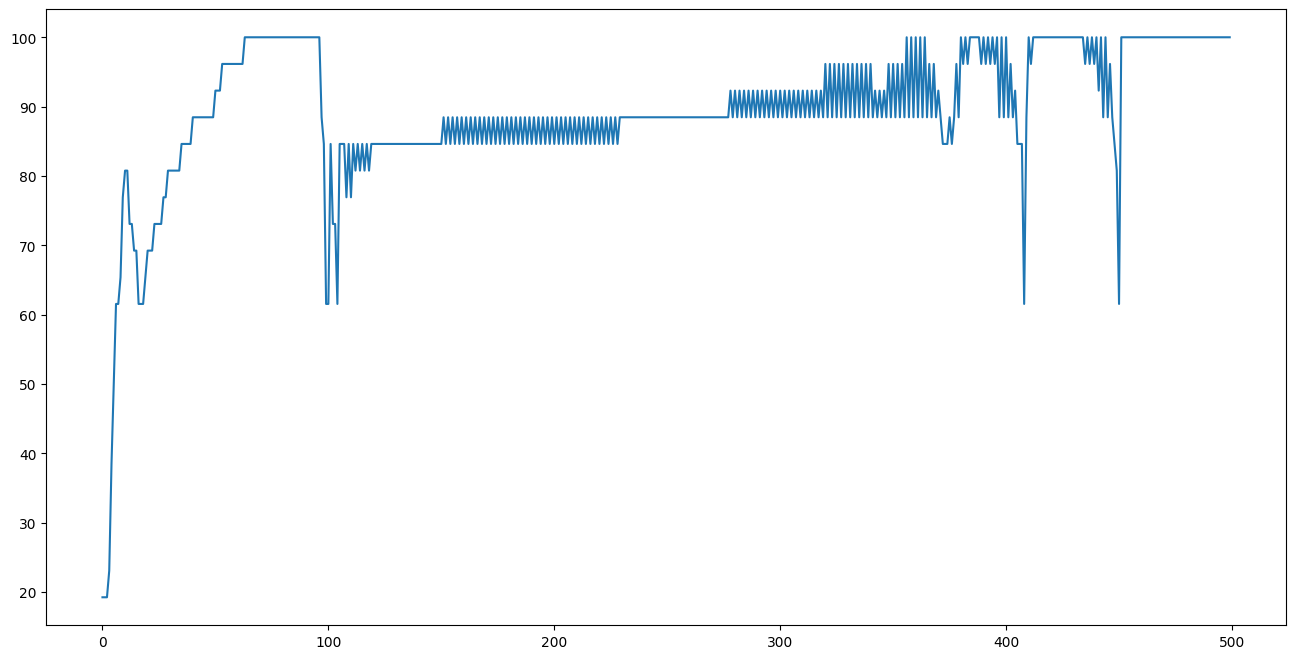

In [77]:
# atualizacao dos pesos a cada epoca
if torch.backends.mps.is_available():
    my_device = torch.device("mps")
elif torch.cuda.is_available():
    my_device = torch.device("cuda:0")
else:
    my_device = torch.device("cpu")
    
print(f"Running on {my_device.type}")
    
# definicao dos hiperparametros e nome do modelo para salvar os logs no tensorboard
dataset_name = 'Iris'
epochs = 500
#lr = 15e-2
lr = 5e-2
lambda_reg = 1e-5
prefix = 'ANN-{}-e-{}-lr-{}'.format(dataset_name, epochs, lr)

net = train( dataset=dataset, epochs=epochs, device=my_device, 
            upper_bound=101.0, lr=lr, lambda_reg=lambda_reg,
            layers2tensorboard=True, save=False, prefix=prefix
           )

Training epochs...:   0%|          | 2/500 [00:00<00:45, 10.93it/s]

Saving the best model at epoch   1 with Accuracy:  65.3846%
Saving the best model at epoch   2 with Accuracy:  73.0769%


Training epochs...:   4%|▎         | 18/500 [00:01<00:41, 11.56it/s]

Saving the best model at epoch  16 with Accuracy:  80.7692%
Saving the best model at epoch  17 with Accuracy:  84.6154%


Training epochs...:   4%|▍         | 20/500 [00:01<00:41, 11.44it/s]

...

Training epochs...:   6%|▌         | 30/500 [00:02<00:43, 10.69it/s]

Saving the best model at epoch  29 with Accuracy:  96.1538%


Training epochs...:  10%|█         | 50/500 [00:04<00:38, 11.73it/s]

Saving the best model at epoch  48 with Accuracy: 100.0000%


Training epochs...: 100%|██████████| 500/500 [00:43<00:00, 11.60it/s]


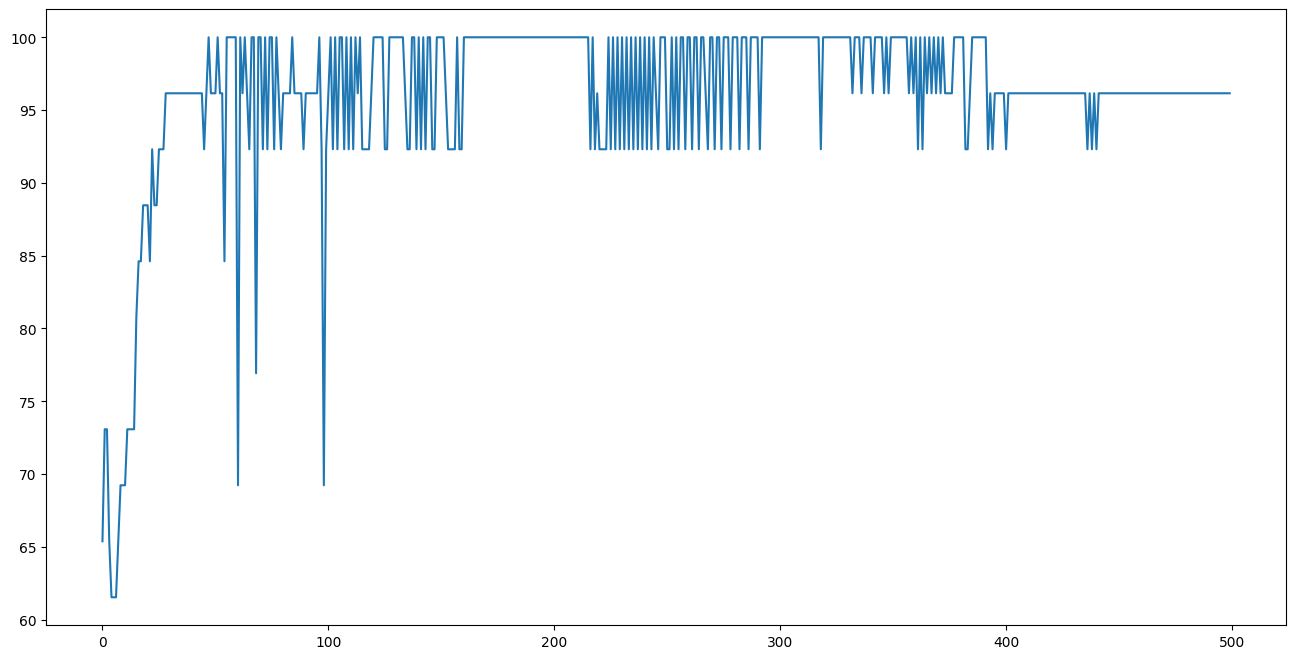

In [78]:
# atualizacao dos pesos a cada exemplo do conjunto de treino

# definicao dos hiperparametros e nome do modelo para salvar os logs no tensorboard
dataset_name = 'Iris'
epochs = 500
lr = 5e-2
lambda_reg = 1e-5
prefix = 'ANN-{}-e-{}-lr-{}'.format(dataset_name, epochs, lr)

net = train( dataset=dataset, epochs=epochs, device=my_device, 
            upper_bound=101.0, lr=lr, lambda_reg=lambda_reg,
            layers2tensorboard=True, save=False, prefix=prefix, update_params=update_params_type.per_sample)

Training epochs...:   1%|          | 4/500 [00:00<00:15, 31.52it/s]

Saving the best model at epoch   1 with Accuracy:  38.4615%
Saving the best model at epoch   2 with Accuracy:  57.6923%
Saving the best model at epoch   3 with Accuracy:  76.9231%


Training epochs...:   5%|▍         | 23/500 [00:00<00:12, 38.77it/s]

Saving the best model at epoch  18 with Accuracy:  88.4615%
Saving the best model at epoch  19 with Accuracy:  92.3077%
Saving the best model at epoch  22 with Accuracy:  96.1538%
Saving the best model at epoch  23 with Accuracy: 100.0000%


Training epochs...: 100%|██████████| 500/500 [00:12<00:00, 41.01it/s]


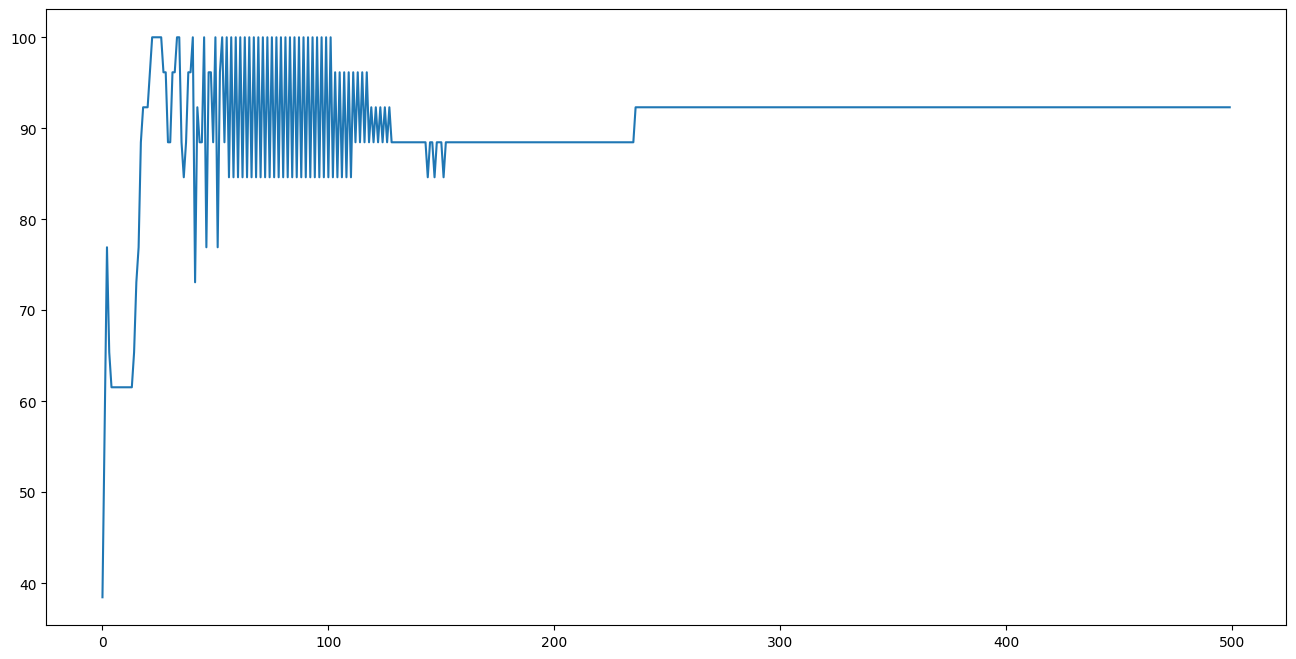

In [79]:
# atualizacao dos pesos por batch de 5 exemplos do conjunto de treino

# definicao dos hiperparametros e nome do modelo para salvar os logs no tensorboard
dataset_name = 'Iris'
epochs = 500
#lr = 15e-2
lr = 5e-2
lambda_reg = 1e-5
prefix = 'ANN-{}-e-{}-lr-{}'.format(dataset_name, epochs, lr)

net = train( dataset=dataset, epochs=epochs, device=my_device, 
            upper_bound=101.0, lr=lr, lambda_reg=lambda_reg,
            layers2tensorboard=True, save=False, prefix=prefix, update_params=update_params_type.per_5_batch)

## Executar o teste

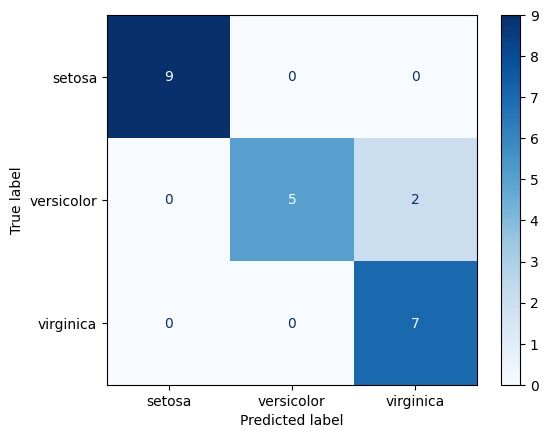

A acurácia do modelo treinado no conjunto de teste é: 91.30% 


In [80]:
accuracy_test = validate ( net , 
                          dataset['test'] , 
                          device=my_device, 
                          confusion_matrix_labels=dataset['class_labels']
                         )
print(f"A acurácia do modelo treinado no conjunto de teste é: {accuracy_test:.2f}% ")

## Teste de inferência única

In [81]:
print(net)

test_x = torch.from_numpy(dataset['test']['data']).float()
test_x = test_x.to(my_device)
test_label = torch.from_numpy(dataset['test']['label']).float()
test_label = test_label.to(my_device)

indice  = np.random.randint(0,dataset['test']['label'].shape[0])

print(f'Entrada do modelo: {test_x[indice].detach().cpu().numpy()}')
output = net(test_x[indice])
print(f'Saída raw do modelo: {output.detach().cpu().numpy()}')
predicted_class = torch.max(output, dim=0)[1]

predicted_class = predicted_class.to('cpu').numpy()

predicted_class_name = dataset['class_labels'][predicted_class]
correct_name = dataset['class_labels'][y_test[indice]]
print("\nHIT" if predicted_class_name == correct_name else "MISS")
print(f"Saída processada do modelo foi {predicted_class_name} e saída correta era {correct_name} para a amostra indice {indice}")

ANN(
  (lin1): Linear(in_features=4, out_features=8, bias=True)
  (act1): ELU(alpha=1.0)
  (lin2): Linear(in_features=8, out_features=8, bias=True)
  (act2): ELU(alpha=1.0)
  (lin3): Linear(in_features=8, out_features=8, bias=True)
  (act3): ELU(alpha=1.0)
  (lin4): Linear(in_features=8, out_features=3, bias=True)
)
Entrada do modelo: [7.1 3.  5.9 2.1]
Saída raw do modelo: [-4.8088765  1.5219291  2.661531 ]

HIT
Saída processada do modelo foi virginica e saída correta era virginica para a amostra indice 4


## áalise do gráfico de accuracy
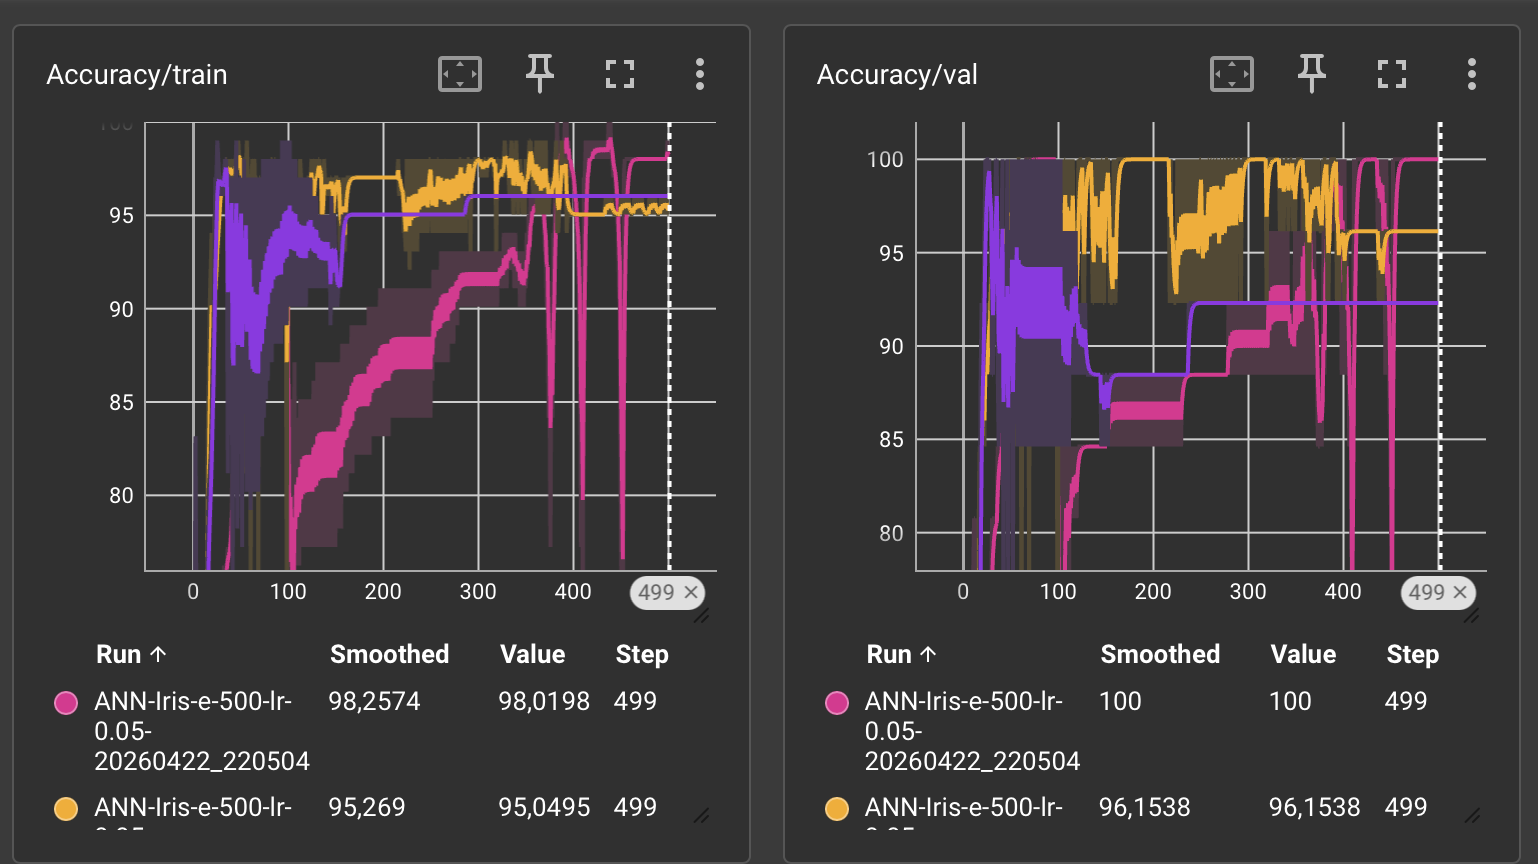

roxo = per_batch, amarelo = per_sample, rosa = per_epoch.

*per_epoch*: curva mais suave e convergência mais lenta e estável. Comportamento parecido na validação, sinal de que o modelo aprendeu.

*per_sample*: oscila muito durante o treino, reflexo dos gradientes ruidosos. comportamento parecido na validação, sinal de que o modelo aprendeu,  mas apenas a analise da curva de acurácia não da a certeza do good fit.

*per_5_batch*: chega mais rápido no 100%, a acurácia cai bastante, mas se estabiliza em ~92%. comportamento parecido na validação, sinal de que o modelo aprendeu.


## análise da loss
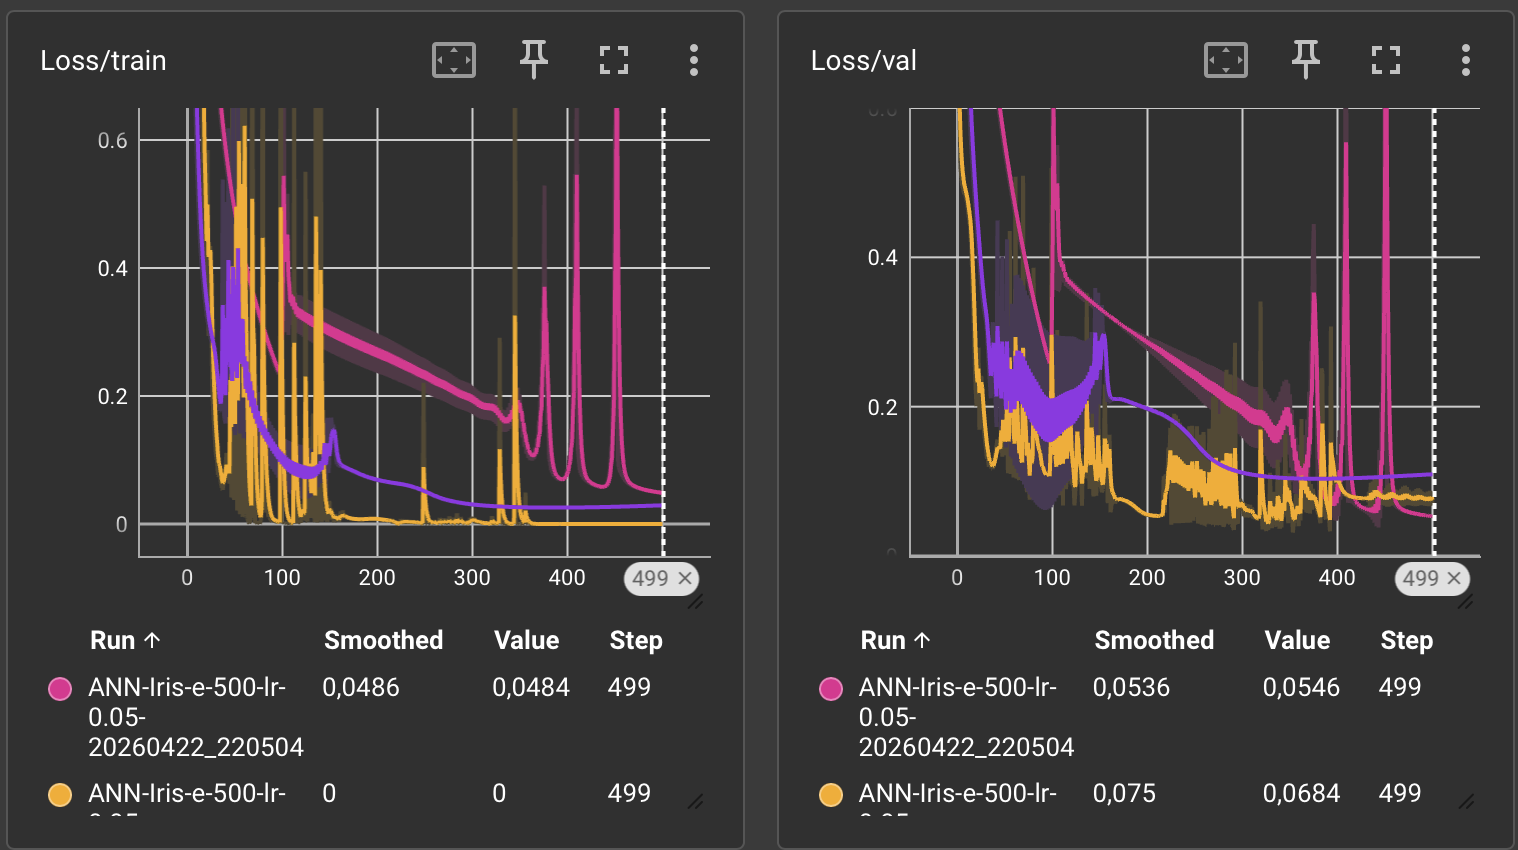

roxo = per_batch, amarelo = per_sample, rosa = per_epoch.

comportamento parecido com a curva de acurácia

*per_epoch*: curva desce de forma mais suave e estável, convergência mais lenta e sólida. No final, perto da época 400, tem uma variação grande. Comportamento parecido na validação, sinal de que o modelo aprendeu.

*per_sample*: oscila muito no início, mas depois cai para 0, sinal de que o modelo memorizou o treino. A curva de validação ficou em ~0.06, confirmando o overfitting (o modelo não generalizou bem).

*per_5_batch*: desce mais rápido que per_epoch, mas com mais oscilações no início.  Comportamento parecido na validação, sinal de que o modelo aprendeu.

## conclusão
*per_epoch* (64 épocas para chegar em 100% de acurácia): 1 atualização por época com gradiente estável (cálculo sobre todos os 101 exemplos). Precisa de mais épocas, mas cada época é rápida.

*per_sample* (48 épocas para chegar em 100% de acurácia): faz 101 atualizações por época, mas os gradientes são muito ruidosos (cálculo sobre 1 exemplo). O ruído pode ajudar a escapar de mínimos locais, mas também atrapalha a convergência.

*per_5_batch* (23 épocas para chegar em 100% de acurácia): melhor resultado. O gradiente calculado sobre ~20 exemplos por batch é mais informativo que 1 amostra e mais frequente que por época. É a melhor abordagem para velocidade e qualidade do gradiente.

Conclusão: per_5_batch foi o mais eficiente tanto em épocas quanto em tempo real. Isso é consistente com a teoria, o mini-batch SGD geralmente supera os dois extremos (batch completo e por amostra).